In [34]:
import torch
import math

def manual_dense_attention(Q, K, V, mask=None):
    """
    Manual dense scaled dot-product attention baseline (Task 1.1).
    Expected input shape: (batch_size, num_heads, seq_len, head_dim)
    """
    d_k = Q.size(-1)

    # 1. Compute raw similarity scores (QK^T)
    #add Query and Key diagram
    # Matrix multiply along the last two dimensions
    scores = torch.matmul(Q, K.transpose(-2, -1))
    # understand K.transpose kyu liya hai
    # 2. Scale by sqrt(d_k)
    scores = scores / math.sqrt(d_k)

    # 3. Apply causal or custom mask if provided
    if mask is not None:
        # Fill masked positions (where mask == 0) with -inf
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # 4. Apply softmax across the key dimension (dim=-1)
    attn_weights = torch.softmax(scores, dim=-1)

    # 5. Multiply probabilities by Values (V)
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

In [35]:
import torch

def create_sliding_window_mask(seq_len, window_size, causal=True):
    """
    Creates a binary mask (seq_len, seq_len) for sliding window attention.
    True = allowed attention, False = masked out.
    """

    i_idx = torch.arange(seq_len).unsqueeze(1)
    j_idx = torch.arange(seq_len).unsqueeze(0)

    # Distance between Query index (i) and Key index (j)
    dist = i_idx - j_idx

    if causal:
        # Token j must be in the past (dist >= 0) and within window (dist <= window_size)
        mask = (dist >= 0) & (dist <= window_size)
    else:
        # Symmetric window around current token
        mask = torch.abs(dist) <= window_size

    return mask


In [5]:
import torch

def create_bigbird_mask(seq_len, window_size, num_global=1, num_random=2, causal=True, seed=None):
    """
    Creates a BigBird sparsity mask combining local sliding window,
    global tokens, and random connections.
    """
    if seed is not None:
        torch.manual_seed(seed)

    # 1. Local Sliding Window
    i_idx = torch.arange(seq_len).unsqueeze(1)
    j_idx = torch.arange(seq_len).unsqueeze(0)
    dist = i_idx - j_idx

    if causal:
        mask = (dist >= 0) & (dist <= window_size)
    else:
        mask = torch.abs(dist) <= window_size

    # 2. Global Tokens
    mask[:num_global, :] = True
    mask[:, :num_global] = True

    # 3. Random Tokens (Select num_random keys for each query row)
    if num_random > 0:
        for i in range(seq_len):
            # Pick 'num_random' random key indices across the sequence length
            rand_indices = torch.randperm(seq_len)[:num_random]
            mask[i, rand_indices] = True

    # 4. Strictly enforce causality across local, global, and random selections
    if causal:
        causal_tri = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool))
        mask = mask & causal_tri

    return mask

In [28]:
import math
import torch


def test_sparse_vs_dense_correctness(dense_fn, sparse_mask_fn):
    """Correctness harness for Item 1.3: Verifies sparse variant outputs

    match the dense baseline on unmasked positions within float tolerance.
    """
    torch.manual_seed(42)

    configs = [
        {"B": 2, "H": 4, "N": 64, "D": 32, "w": 8, "g": 1},
        {"B": 1, "H": 8, "N": 128, "D": 64, "w": 16, "g": 2},
        {"B": 4, "H": 2, "N": 256, "D": 32, "w": 32, "g": 4},
    ]

    for idx, cfg in enumerate(configs):
        B, H, N, D = cfg["B"], cfg["H"], cfg["N"], cfg["D"]
        w, g = cfg["w"], cfg["g"]

        Q = torch.randn(B, H, N, D)
        K = torch.randn(B, H, N, D)
        V = torch.randn(B, H, N, D)

        # 1. Generate the sparse mask
        #mask = sparse_mask_fn(seq_len=N, window_size=w, num_global=g, num_random=2, causal=True, seed=42)
        mask = sparse_mask_fn(seq_len=N, window_size=w, causal=True)

        # 2. Reference raw dense scores: QK^T / sqrt(d_k)
        d_k = D
        raw_dense_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        # 3. Compute sparse scores using dense_fn with the sparse mask
        # Inside dense_fn: scores = (QK^T / sqrt(d_k)).masked_fill(mask == 0, float('-inf'))
        # We compute sparse_raw_scores before -inf replacement to verify equivalence on mask==True
        mask_4d = mask.unsqueeze(0).unsqueeze(0).expand(B, H, N, N)

        # Evaluate sparse implementation / masked dot-product scores
        sparse_scores = raw_dense_scores.masked_fill(~mask_4d, float("-inf"))

        # 4. Extract scores on unmasked (active) positions
        unmasked_dense_scores = raw_dense_scores[mask_4d]
        unmasked_sparse_scores = sparse_scores[mask_4d]

        # 5. Numerical tolerance assertion (rtol/atol for float32 rounding)
        passed = torch.allclose(
            unmasked_dense_scores, unmasked_sparse_scores, rtol=1e-4, atol=1e-5
        )

        print(
            f"Config {idx+1} [Seq Len {N}]: "
            f"{'PASSED' if passed else 'FAILED'} | "
            f"Active Elements Verified: {unmasked_dense_scores.numel()}"
        )

        assert passed, f"Mismatch found in configuration {cfg}"


# Example tests for both sliding window and BigBird masks:
test_sparse_vs_dense_correctness(manual_dense_attention, create_sliding_window_mask)
#test_sparse_vs_dense_correctness(manual_dense_attention, create_bigbird_mask)

Config 1 [Seq Len 64]: PASSED | Active Elements Verified: 4320
Config 2 [Seq Len 128]: PASSED | Active Elements Verified: 16320
Config 3 [Seq Len 256]: PASSED | Active Elements Verified: 63360


In [ ]:
import torch
import math

def manual_dense_attention_NaN_Handled(Q, K, V, mask=None):
    """
    Manual dense scaled dot-product attention baseline (Task 1.1).
    Expected input shape: (batch_size, num_heads, seq_len, head_dim)
    """
    d_k = Q.size(-1)

    # 1. Compute raw similarity scores (QK^T)
    # Matrix multiply along the last two dimensions
    scores = torch.matmul(Q, K.transpose(-2, -1))
    # understand K.transpose kyu liya hai
    # 2. Scale by sqrt(d_k)
    scores = scores / math.sqrt(d_k)

    # 3. Apply causal or custom mask if provided
    if mask is not None:
        # Fill masked positions (where mask == 0) with -inf
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # 4. Apply softmax across the key dimension (dim=-1) and zero out NaN probabilitieis
    attn_weights = torch.softmax(scores, dim=-1)
    attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

    # 5. Multiply probabilities by Values (V)
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

Benchmarking Sequence Length: 512...
Benchmarking Sequence Length: 1024...
Benchmarking Sequence Length: 2048...
Benchmarking Sequence Length: 4096...
Benchmarking Sequence Length: 8192...


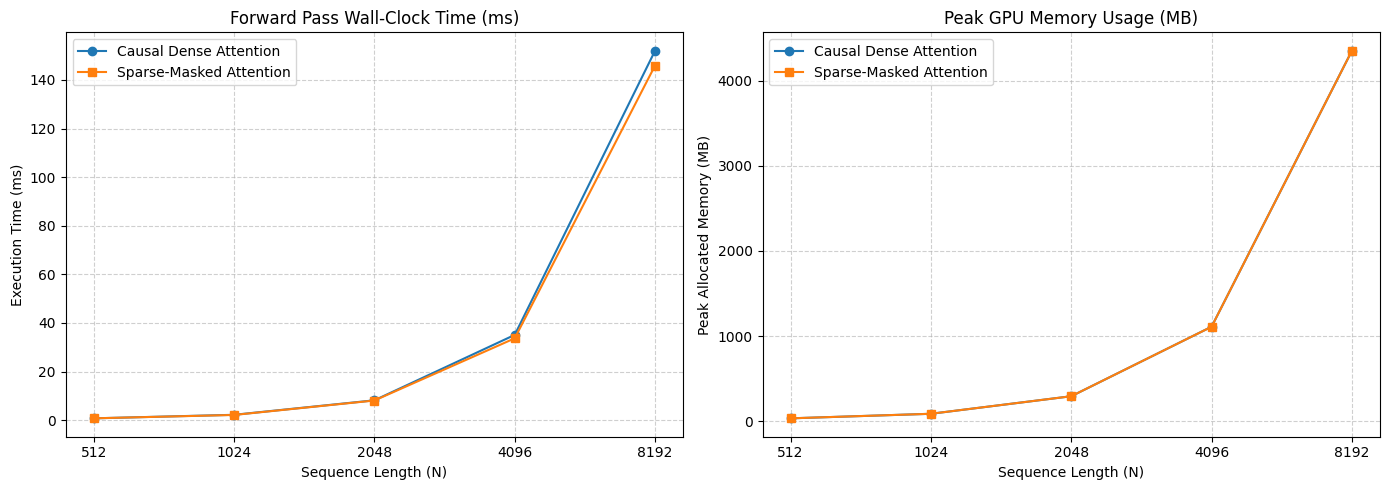

In [32]:
import torch
import math
import time
import matplotlib.pyplot as plt


# --- BENCHMARK HARNESS ---
def benchmark_attention():
    if not torch.cuda.is_available():
        raise SystemError("CUDA GPU is required for accurate memory & wall-clock profiling.")

    device = torch.device("cuda")

    # Configurations
    batch_size = 1
    num_heads = 8
    head_dim = 64
    seq_lengths = [512, 1024, 2048, 4096, 8192]
    num_warmup = 5
    num_iters = 20

    results = {
        "dense_time": [], "dense_mem": [],
        "sparse_time": [], "sparse_mem": []
    }

    for N in seq_lengths:
        print(f"Benchmarking Sequence Length: {N}...")

        Q = torch.randn(batch_size, num_heads, N, head_dim, device=device)
        K = torch.randn(batch_size, num_heads, N, head_dim, device=device)
        V = torch.randn(batch_size, num_heads, N, head_dim, device=device)

        # Causal mask for dense attention (True where attention is allowed)
        causal_mask = torch.tril(torch.ones(N, N, device=device, dtype=torch.bool))
        sparse_mask = create_bigbird_mask(N, window_size=64, num_global=2, num_random=3, causal=True).to(device)

        # 1. Causal Dense Attention Benchmark
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

        # Warmup
        for _ in range(num_warmup):
            _ = manual_dense_attention(Q, K, V, mask=causal_mask)

        torch.cuda.synchronize()

        start_evt = torch.cuda.Event(enable_timing=True)
        end_evt = torch.cuda.Event(enable_timing=True)

        start_evt.record()
        for _ in range(num_iters):
            _ = manual_dense_attention(Q, K, V, mask=causal_mask)

        end_evt.record()
        torch.cuda.synchronize()

        dense_time = start_evt.elapsed_time(end_evt) / num_iters  # ms
        dense_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        results["dense_time"].append(dense_time)
        results["dense_mem"].append(dense_mem)

        # 2. Sparse Attention Benchmark (Masked Dense Baseline Execution)
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

        # Warmup
        for _ in range(num_warmup):
            _ = manual_dense_attention(Q, K, V, mask=sparse_mask)
        torch.cuda.synchronize()

        start_evt = torch.cuda.Event(enable_timing=True)
        end_evt = torch.cuda.Event(enable_timing=True)

        start_evt.record()
        for _ in range(num_iters):
            _ = manual_dense_attention(Q, K, V, mask=sparse_mask)
        end_evt.record()
        torch.cuda.synchronize()

        sparse_time = start_evt.elapsed_time(end_evt) / num_iters  # ms
        sparse_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        results["sparse_time"].append(sparse_time)
        results["sparse_mem"].append(sparse_mem)

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Latency Plot
    ax1.plot(seq_lengths, results["dense_time"], marker='o', label='Causal Dense Attention')
    ax1.plot(seq_lengths, results["sparse_time"], marker='s', label='Sparse-Masked Attention')
    ax1.set_title('Forward Pass Wall-Clock Time (ms)')
    ax1.set_xlabel('Sequence Length (N)')
    ax1.set_ylabel('Execution Time (ms)')
    ax1.set_xscale('log', base=2)
    ax1.set_xticks(seq_lengths)
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Memory Plot
    ax2.plot(seq_lengths, results["dense_mem"], marker='o', label='Causal Dense Attention')
    ax2.plot(seq_lengths, results["sparse_mem"], marker='s', label='Sparse-Masked Attention')
    ax2.set_title('Peak GPU Memory Usage (MB)')
    ax2.set_xlabel('Sequence Length (N)')
    ax2.set_ylabel('Peak Allocated Memory (MB)')
    ax2.set_xscale('log', base=2)
    ax2.set_xticks(seq_lengths)
    ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.savefig("attention_benchmark.png")
    plt.show()

if __name__ == "__main__":
    benchmark_attention()

In [ ]:

# TASK 1.6 — Quality Evaluation on TinyShakespeare
# 2-layer character-level GPT: Dense vs Sparse Attention


import torch
import torch.nn as nn
import torch.nn.functional as F
import urllib.request
import time
import math

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type != "cuda":
    print("WARNING: This experiment is intended to be run on a T4 GPU.")


# ------------------------------------------------------------
# 2. Load TinyShakespeare
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

try:
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()
except FileNotFoundError:
    urllib.request.urlretrieve(url, "input.txt")
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()

print("Dataset characters:", len(text))

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)

# 90/10 train-validation split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Vocabulary size:", vocab_size)
print("Training characters:", len(train_data))
print("Validation characters:", len(val_data))



# 3. Hyperparameters


batch_size = 64
block_size = 256

n_embd = 128
n_head = 4
n_layer = 2

dropout = 0.0

learning_rate = 3e-4

# Approximately 10 minutes on a T4 depending on environment.
max_iters = 5000

eval_interval = 500
eval_iters = 100

# Sparse attention parameters
window_size = 32
num_global = 2
num_random = 2


# 4. Batch generation


def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(
        len(source) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        source[i:i + block_size]
        for i in ix
    ])

    y = torch.stack([
        source[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)



# 5. Attention head


class Head(nn.Module):

    def __init__(self, head_size, attention_type):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.attention_type = attention_type

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Convert to:
        # (B, 1, T, head_size)
        q = q.unsqueeze(1)
        k = k.unsqueeze(1)
        v = v.unsqueeze(1)


        # Build attention mask


        if self.attention_type == "dense":

            mask = torch.tril(
                torch.ones(T, T, dtype=torch.bool, device=x.device)
            )

        elif self.attention_type == "sliding":

            mask = create_sliding_window_mask(
                seq_len=T,
                window_size=window_size,
                causal=True
            ).to(x.device)

        elif self.attention_type == "bigbird":

            mask = create_bigbird_mask(
                seq_len=T,
                window_size=window_size,
                num_global=num_global,
                num_random=num_random,
                causal=True,

            ).to(x.device)

        else:
            raise ValueError(
                f"Unknown attention type: {self.attention_type}"
            )


        # Use the attention implementation from the notebook


        out, weights = manual_dense_attention_NaN_Handled(
            q,
            k,
            v,
            mask=mask
        )

        # (B, 1, T, head_size) -> (B, T, head_size)
        out = out.squeeze(1)

        return self.dropout(out)



# 6. Multi-head attention


class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size, attention_type):
        super().__init__()

        self.heads = nn.ModuleList([
            Head(head_size, attention_type)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        return self.dropout(self.proj(out))



# 7. Feed-forward network


class FeedForward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


# 8. Transformer block


class Block(nn.Module):

    def __init__(self, attention_type):
        super().__init__()

        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(
            n_head,
            head_size,
            attention_type
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))

        return x



# 9. 2-layer character-level GPT


class GPT(nn.Module):

    def __init__(self, attention_type):

        super().__init__()

        self.attention_type = attention_type

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        self.blocks = nn.Sequential(
            Block(attention_type),
            Block(attention_type)
        )

        self.ln_f = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(
            n_embd,
            vocab_size
        )

        # Better initialization
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)

        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss


# 10. Evaluation


@torch.no_grad()
def estimate_loss(model):

    model.eval()

    losses = {}

    for split in ["train", "val"]:

        loss_values = torch.zeros(eval_iters)

        for k in range(eval_iters):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            loss_values[k] = loss.item()

        losses[split] = loss_values.mean().item()

    model.train()

    return losses



# 11. Train one model


def train_model(attention_type):

    print("\n" + "=" * 60)
    print("Training:", attention_type)
    print("=" * 60)

    model = GPT(attention_type).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    start_time = time.time()

    for iteration in range(max_iters):

        if iteration % eval_interval == 0 or iteration == max_iters - 1:

            losses = estimate_loss(model)

            elapsed = time.time() - start_time

            print(
                f"{attention_type:8s} | "
                f"step {iteration:5d} | "
                f"train loss {losses['train']:.4f} | "
                f"val loss {losses['val']:.4f} | "
                f"time {elapsed / 60:.1f} min"
            )

        X, Y = get_batch("train")

        logits, loss = model(X, Y)

        optimizer.zero_grad(set_to_none=True)

        loss.backward()

        optimizer.step()

    final_losses = estimate_loss(model)

    total_time = time.time() - start_time

    print(
        f"\nFinished {attention_type} "
        f"in {total_time / 60:.2f} minutes"
    )

    print(
        f"Final train loss: {final_losses['train']:.4f}"
    )

    print(
        f"Final validation loss: {final_losses['val']:.4f}"
    )

    return model, final_losses



# 12. Run the three experiments


results = {}

models = {}

for attention_type in [
    "dense",
    "sliding",
    "bigbird"
]:

    model, losses = train_model(attention_type)

    models[attention_type] = model
    results[attention_type] = losses


# 13. Final Task 1.6 table


print("\n")
print("=" * 60)
print("TASK 1.6 — FINAL RESULTS")
print("=" * 60)

print(
    f"{'Pattern':<15}"
    f"{'Train Loss':>15}"
    f"{'Validation Loss':>20}"
)

print("-" * 50)

for name, losses in results.items():

    print(
        f"{name:<15}"
        f"{losses['train']:>15.4f}"
        f"{losses['val']:>20.4f}"
    )

print("=" * 60)

Using device: cuda
Dataset characters: 1115394
Vocabulary size: 65
Training characters: 1003854
Validation characters: 111540

Training: dense
dense    | step     0 | train loss 4.1690 | val loss 4.1671 | time 0.1 min
dense    | step   500 | train loss 2.1604 | val loss 2.1967 | time 0.6 min
dense    | step  1000 | train loss 1.7316 | val loss 1.8738 | time 1.0 min
dense    | step  1500 | train loss 1.5830 | val loss 1.7597 | time 1.5 min
dense    | step  2000 | train loss 1.5148 | val loss 1.7045 | time 1.9 min
dense    | step  2500 | train loss 1.4628 | val loss 1.6674 | time 2.4 min
dense    | step  3000 | train loss 1.4391 | val loss 1.6446 | time 2.9 min
dense    | step  3500 | train loss 1.4166 | val loss 1.6325 | time 3.3 min
dense    | step  4000 | train loss 1.3924 | val loss 1.6325 | time 3.8 min
dense    | step  4500 | train loss 1.3780 | val loss 1.6182 | time 4.2 min
dense    | step  4999 | train loss 1.3567 | val loss 1.6060 | time 4.7 min

Finished dense in 4.75 minutes


In [ ]:

# TASK 1.6 Quality Evaluation on TinyShakespeare
# 2-layer character-level GPT: Dense vs Sparse Attention

#same code but hyperparameters tuned
import torch
import torch.nn as nn
import torch.nn.functional as F
import urllib.request
import time
import math


# 1. Device


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type != "cuda":
    print("WARNING: This experiment is intended to be run on a T4 GPU.")



# 2. Load TinyShakespeare


url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

try:
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()
except FileNotFoundError:
    urllib.request.urlretrieve(url, "input.txt")
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()

print("Dataset characters:", len(text))

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)

# 90/10 train-validation split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Vocabulary size:", vocab_size)
print("Training characters:", len(train_data))
print("Validation characters:", len(val_data))



# 3. Hyperparameters


batch_size = 64
block_size = 256

n_embd = 256
n_head = 4
n_layer = 2

dropout = 0.2

learning_rate = 1e-3

# Approximately 10 minutes on a T4 depending on environment.
max_iters = 2500

eval_interval = 500
eval_iters = 100

# Sparse attention parameters
window_size = 32
num_global = 2
num_random = 2



# 4. Batch generation


def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(
        len(source) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        source[i:i + block_size]
        for i in ix
    ])

    y = torch.stack([
        source[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)



# 5. Attention head


class Head(nn.Module):

    def __init__(self, head_size, attention_type):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.attention_type = attention_type

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Convert to:
        # (B, 1, T, head_size)
        q = q.unsqueeze(1)
        k = k.unsqueeze(1)
        v = v.unsqueeze(1)


        # Build attention mask


        if self.attention_type == "dense":

            mask = torch.tril(
                torch.ones(T, T, dtype=torch.bool, device=x.device)
            )

        elif self.attention_type == "sliding":

            mask = create_sliding_window_mask(
                seq_len=T,
                window_size=window_size,
                causal=True
            ).to(x.device)

        elif self.attention_type == "bigbird":

            mask = create_bigbird_mask(
                seq_len=T,
                window_size=window_size,
                num_global=num_global,
                num_random=num_random,
                causal=True,

            ).to(x.device)

        else:
            raise ValueError(
                f"Unknown attention type: {self.attention_type}"
            )


        # Use the attention implementation from the notebook


        out, weights = manual_dense_attention_NaN_Handled(
            q,
            k,
            v,
            mask=mask
        )

        # (B, 1, T, head_size) -> (B, T, head_size)
        out = out.squeeze(1)

        return self.dropout(out)



# 6. Multi-head attention

class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size, attention_type):
        super().__init__()

        self.heads = nn.ModuleList([
            Head(head_size, attention_type)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        return self.dropout(self.proj(out))



# 7. Feed-forward network


class FeedForward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)



# 8. Transformer block


class Block(nn.Module):

    def __init__(self, attention_type):
        super().__init__()

        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(
            n_head,
            head_size,
            attention_type
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))

        return x



# 9. 2-layer character-level GPT


class GPT(nn.Module):

    def __init__(self, attention_type):

        super().__init__()

        self.attention_type = attention_type

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        self.blocks = nn.Sequential(
            Block(attention_type),
            Block(attention_type)
        )

        self.ln_f = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(
            n_embd,
            vocab_size
        )

        # Better initialization
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(self, idx, targets=None):

        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)

        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss



# 10. Evaluation


@torch.no_grad()
def estimate_loss(model):

    model.eval()

    losses = {}

    for split in ["train", "val"]:

        loss_values = torch.zeros(eval_iters)

        for k in range(eval_iters):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            loss_values[k] = loss.item()

        losses[split] = loss_values.mean().item()

    model.train()

    return losses



# 11. Train one model


def train_model(attention_type):

    print("\n" + "=" * 60)
    print("Training:", attention_type)
    print("=" * 60)

    model = GPT(attention_type).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    start_time = time.time()

    for iteration in range(max_iters):

        if iteration % eval_interval == 0 or iteration == max_iters - 1:

            losses = estimate_loss(model)

            elapsed = time.time() - start_time

            print(
                f"{attention_type:8s} | "
                f"step {iteration:5d} | "
                f"train loss {losses['train']:.4f} | "
                f"val loss {losses['val']:.4f} | "
                f"time {elapsed / 60:.1f} min"
            )

        X, Y = get_batch("train")

        logits, loss = model(X, Y)

        optimizer.zero_grad(set_to_none=True)

        loss.backward()

        optimizer.step()

    final_losses = estimate_loss(model)

    total_time = time.time() - start_time

    print(
        f"\nFinished {attention_type} "
        f"in {total_time / 60:.2f} minutes"
    )

    print(
        f"Final train loss: {final_losses['train']:.4f}"
    )

    print(
        f"Final validation loss: {final_losses['val']:.4f}"
    )

    return model, final_losses


# 12. Run the three experiments


results = {}

models = {}

for attention_type in [
    "dense",
    "sliding",
    "bigbird"
]:

    model, losses = train_model(attention_type)

    models[attention_type] = model
    results[attention_type] = losses


# 13. Final Task 1.6 table


print("\n")
print("=" * 60)
print("TASK 1.6 — FINAL RESULTS")
print("=" * 60)

print(
    f"{'Pattern':<15}"
    f"{'Train Loss':>15}"
    f"{'Validation Loss':>20}"
)

print("-" * 50)

for name, losses in results.items():

    print(
        f"{name:<15}"
        f"{losses['train']:>15.4f}"
        f"{losses['val']:>20.4f}"
    )

print("=" * 60)

Using device: cuda
Dataset characters: 1115394
Vocabulary size: 65
Training characters: 1003854
Validation characters: 111540

Training: dense
dense    | step     0 | train loss 4.3023 | val loss 4.3000 | time 0.1 min
dense    | step   500 | train loss 1.5826 | val loss 1.7853 | time 1.1 min
dense    | step  1000 | train loss 1.4130 | val loss 1.6407 | time 2.0 min
dense    | step  1500 | train loss 1.3298 | val loss 1.5867 | time 2.9 min
dense    | step  2000 | train loss 1.2912 | val loss 1.5709 | time 3.9 min
dense    | step  2499 | train loss 1.2596 | val loss 1.5441 | time 4.8 min

Finished dense in 4.92 minutes
Final train loss: 1.2589
Final validation loss: 1.5445

Training: sliding
sliding  | step     0 | train loss 4.2399 | val loss 4.2401 | time 0.1 min
sliding  | step   500 | train loss 1.5017 | val loss 1.7132 | time 1.0 min
sliding  | step  1000 | train loss 1.3724 | val loss 1.5983 | time 1.9 min
sliding  | step  1500 | train loss 1.3120 | val loss 1.5728 | time 2.9 min
s